# TideGAN Dataset — Random Sample Visualization

Loads 20 random samples from the `TideGANDataset` and displays the reference image, target image, and tide info for each.

In [4]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

from tidegan_dataset import TideGANDataset

# Load dataset (no augment so images are clean)
dataset = TideGANDataset(patch_size=256, augment=False)
print(f"Dataset has {len(dataset)} samples (infinite iterator)")
print(f"Sites: {dataset.sites_list}")

Dataset cargado. Rango de marea global: [-2.178m, 1.186m]
[Foz] Aviso: No se encontró referencia sin nubes. Usando marea más baja por defecto.
[Santander] Referencia fija: 2025-03-31 (Marea: -2.178m, Nubes: 0.1%)
[Villaviciosa] Aviso: No se encontró referencia sin nubes. Usando marea más baja por defecto.
Dataset has 100000 samples (infinite iterator)
Sites: ['Foz', 'Santander', 'Villaviciosa']


In [5]:
def tensor_to_image(tensor):
    """Convert (3, H, W) tensor in [-1, 1] to (H, W, 3) numpy in [0, 255]."""
    img = tensor.cpu().numpy().transpose(1, 2, 0)  # (H, W, 3)
    img = (img + 1.0) / 2.0 * 255.0                # [-1,1] → [0,255]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img


def denormalize_tide(norm_tide):
    """Inverse of the global _normalize_tide from tidegan_dataset."""
    global_min = dataset.global_min_tide
    global_max = dataset.global_max_tide
    return (norm_tide + 1.0) / 2.0 * (global_max - global_min) + global_min


def format_condition(cond):
    """Parse condition vector into human-readable info."""
    norm_tide = cond[0].item()
    real_tide = denormalize_tide(norm_tide)
    return real_tide, norm_tide


def make_tide_colors():
    """Create a (20, 4) gradient from blue (low tide) through white to red (high tide)."""
    colors = np.ones((20, 4))
    for j in range(20):
        t = j / 19.0
        if t < 0.5:
            colors[j] = [0.27 + t * 1.46, 0.35 + t * 1.3, 0.55 + t * 0.9, 1.0]
        else:
            colors[j] = [0.98 - (t - 0.5) * 0.98, 0.98 - (t - 0.5) * 0.63, 0.98 - (t - 0.5) * 0.43, 1.0]
    return colors


TIDE_COLORS = make_tide_colors()
TIDE_RANGE = (-2.5, 2.5)  # reasonable range for all sites

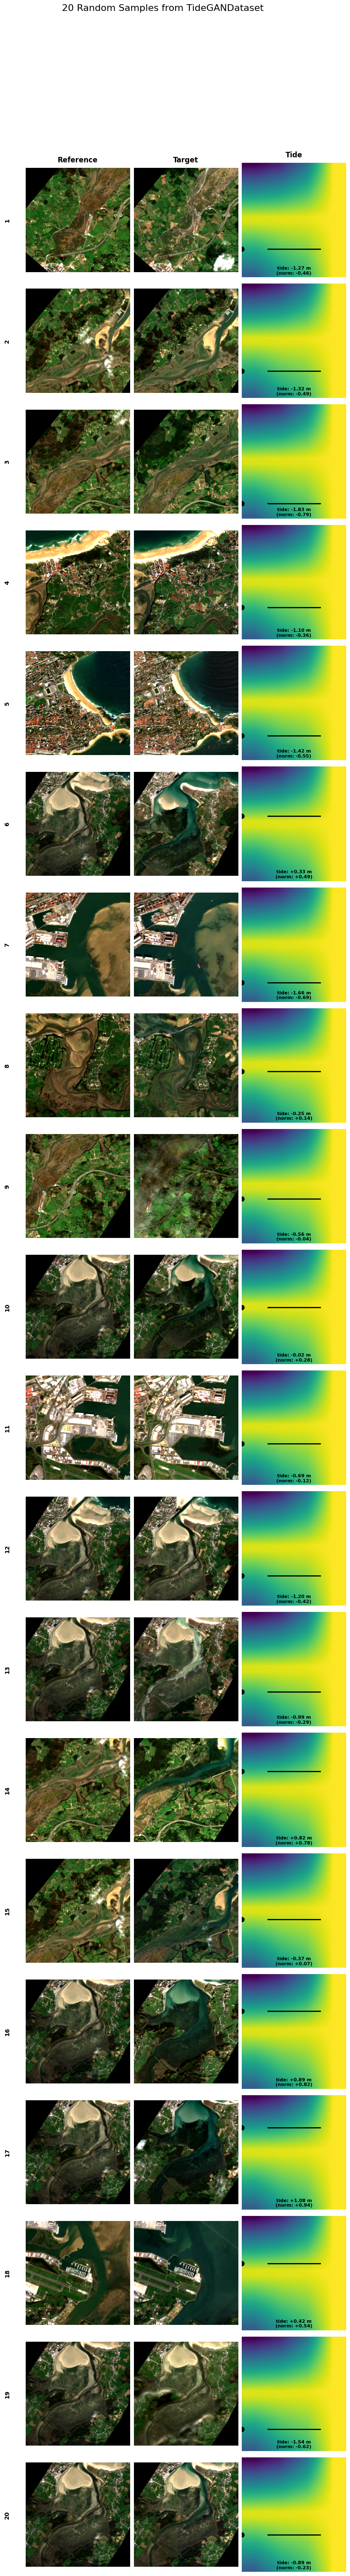

Saved 20 samples → dataset_samples.png


In [6]:
# ── Draw 20 random samples ───────────────────────────────────────────
n_samples = 20

# We'll draw from different random indices
indices = torch.randint(0, 10000, size=(n_samples,)).tolist()

# 3 columns (ref, target, tide) × 20 rows
n_cols = 3
n_rows = n_samples

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows * 3), squeeze=False)

for row in range(n_rows):
    idx = indices[row]
    ref, target, cond = dataset[idx]
    tide_m, norm_tide = format_condition(cond)

    ref_img = tensor_to_image(ref)
    target_img = tensor_to_image(target)

    # ── Column 0: Reference image ──
    ax0 = axes[row, 0]
    ax0.imshow(ref_img)
    ax0.axis("off")

    # ── Column 1: Target image ──
    ax1 = axes[row, 1]
    ax1.imshow(target_img)
    ax1.axis("off")

    # ── Column 2: Tide bar + info ──
    ax2 = axes[row, 2]
    ax2.axis("off")

    # Normalize tide level to [0, 1] for the bar
    tmin, tmax = TIDE_RANGE
    frac = (tide_m - tmin) / (tmax - tmin)
    frac = np.clip(frac, 0, 1)

    # Show the tide color gradient
    ax2.imshow(TIDE_COLORS, extent=[0, 1, 0, 1], aspect='auto', interpolation='bilinear')

    # Mark current tide level on the bar
    ax2.plot([0.25, 0.75], [frac, frac], color='black', linewidth=2)
    ax2.plot([0.0], [frac], 'o', color='black', markersize=8)

    # Tide info text
    ax2.text(0.5, 0.02, f"tide: {tide_m:+.2f} m\n(norm: {norm_tide:+.2f})", 
             ha='center', va='bottom', fontsize=8, fontweight='bold',
             transform=ax2.transAxes)

# Column headers
for i, label in enumerate(["Reference", "Target", "Tide"]):
    axes[0, i].set_title(label, fontsize=12, fontweight='bold', pad=10)

# Row labels with sample numbers
for row in range(n_rows):
    axes[row, 0].text(-0.15, 0.5, f"{row + 1}", fontsize=10, fontweight='bold',
                      va='center', ha='right', rotation='vertical',
                      transform=axes[row, 0].transAxes)

plt.suptitle(f"20 Random Samples from TideGANDataset", fontsize=16, y=1.02)
plt.tight_layout(rect=[0.08, 0, 1, 0.97])
plt.savefig("dataset_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 20 samples → dataset_samples.png")